

**Problem 1 – Customer Behavioral Segmentation (Mall of America)**  





## **Contents**
1. [Project Setup & Data Dictionary](#setup)
2. [EDA: Structure, Distributions, Outliers, Relationships](#eda)
3. [Q1 — Filtering Employees & Short Visits](#q1)
4. [Feature Engineering for Floors (Percentages)](#floors-fe)
5. [Q2 — Floor-Based Segmentation (K‑Means)](#q2)
    - 5.1. Choose *K* via Elbow & Silhouette  
    - 5.2. Train Final Model & Label Data  
    - 5.3. Cluster Profiling (Tables & Charts)  
    - 5.4. PCA Visualization (2D)  
    - 5.5. Interpretation (ready-to-copy text)
6. [Q3 — Section-Level Sub‑Segmentation of Dominant-Floor Cluster](#q3)
    - 6.1. Pick Dominant Cluster & Floor  
    - 6.2. Feature Engineering (Section Percentages)  
    - 6.3. Choose *K*, Train, Profile, Visualize  
    - 6.4. Interpretation (ready-to-copy text)
7. [Conclusions & Business Actions](#conclusion)


## <a id='setup'></a> 1. Project Setup & Data Dictionary

In [1]:

# Core imports
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# Paths
DATA_PATH = Path('/content/moa_customer_segments (1).xlsx')
assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'

# Load
df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = [str(c).strip().lower().replace(' ', '_') for c in df_raw.columns]
print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (7705, 31)


,device,session_date,apple_flag,entry_time,exit_time,duration,time_0_1,time_0,time_1,time_2,...,time_3_e,time_3_n,time_3_ne,time_3_nex,time_3_nw,time_3_s,time_3_se,time_3_sw,time_3_w,employee_flag
0,device:00:c6:10:ab:d8:20,2016-01-01,1,2016-01-01 12:36:29.010,2016-01-01 17:54:10.250,19061.0,0,0.0,14403.0,4658,...,0.0,0,0,0,0,0,0,0,0,0
1,device:04:4b:ed:06:ee:68,2016-01-01,1,2016-01-01 12:59:53.390,2016-01-01 16:11:50.190,11517.0,0,0.0,2364.0,4970,...,0.0,123,37,0,105,2048,0,1511,332,0
2,device:04:f1:3e:e2:ce:81,2016-01-01,1,2016-01-01 09:37:13.370,2016-01-01 20:36:14.700,39541.0,0,0.0,0.0,0,...,0.0,0,0,0,0,38902,0,553,86,1
3,device:08:74:02:06:bc:66,2016-01-01,1,2016-01-01 11:15:56.060,2016-01-01 18:06:46.630,24650.0,0,0.0,1631.0,21602,...,48.0,434,46,878,0,0,0,0,0,1
4,device:0c:15:39:2d:0f:75,2016-01-01,1,2016-01-01 17:06:38.920,2016-01-01 22:50:27.310,20629.0,0,1713.0,2572.0,1169,...,19.0,0,10711,0,48,989,0,1228,42,0



**Data dictionary (key fields):**
- `device` – unique device ID (proxy for customer)
- `session_date` – date of unique visit (4 AM–4 AM window)
- `entry_time`, `exit_time` – first/last Wi‑Fi session timestamp
- `duration` – total visit time (**seconds**)
- `time_0`–`time_4` – total time on floors **L0..L4** (seconds)
- `time_2_*`, `time_3_*` – section times for floors 2 & 3 (e.g., `time_3_n`, `time_3_w`, ...)
- `employee_flag` – 1 if device belongs to an employee


## <a id='eda'></a> 2. EDA: Structure, Distributions, Outliers, Relationships

In [2]:

# Basic structure
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7705 entries, 0 to 7704
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   device         7705 non-null   object        
 1   session_date   7705 non-null   datetime64[ns]
 2   apple_flag     7705 non-null   int64         
 3   entry_time     7705 non-null   datetime64[ns]
 4   exit_time      7705 non-null   datetime64[ns]
 5   duration       7702 non-null   float64       
 6   time_0_1       7705 non-null   int64         
 7   time_0         7704 non-null   float64       
 8   time_1         7704 non-null   float64       
 9   time_2         7705 non-null   int64         
 10  time_3         7704 non-null   float64       
 11  time_4         7705 non-null   int64         
 12  time_2_e       7705 non-null   int64         
 13  time_2_n       7705 non-null   int64         
 14  time_2_ne      7705 non-null   int64         
 15  time_2_nex     7705 n

In [3]:

# Descriptives for durations & floor totals
floors = ['time_0','time_1','time_2','time_3','time_4']
sec3 = [c for c in df_raw.columns if c.startswith('time_3_') and c!='time_3']
sec2 = [c for c in df_raw.columns if c.startswith('time_2_') and c!='time_2']

desc = df_raw[['duration']+floors].describe().T
desc


,count,mean,std,min,25%,50%,75%,max
duration,7702.0,11505.364970,13577.732869,6.0,1999.75,7131.0,16297.75,86372.0
time_0,7704.0,2356.883307,10239.739526,0.0,0.00,0.0,0.00,86372.0
time_1,7704.0,4054.160047,6715.550061,0.0,0.00,1059.5,4916.00,49011.0
time_2,7705.0,1803.679429,4251.217334,0.0,0.00,244.0,1787.00,47539.0
time_3,7704.0,2463.241303,4835.124084,0.0,0.00,554.5,3061.00,77899.0
time_4,7705.0,653.147437,2511.563528,0.0,0.00,0.0,3.00,37658.0


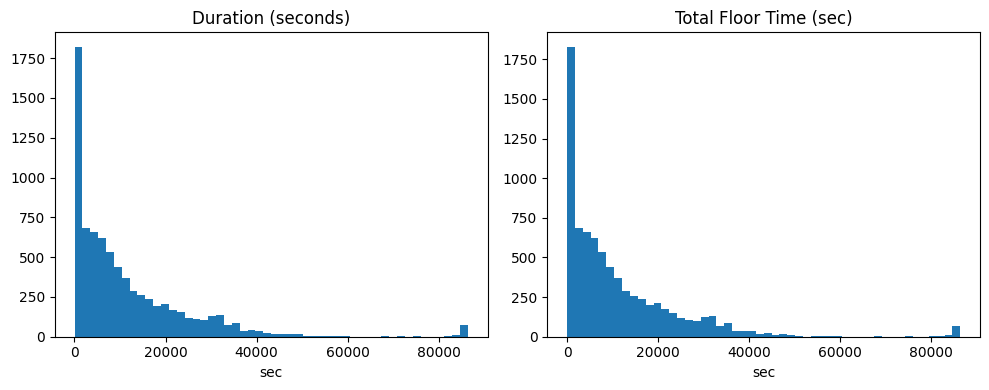

In [4]:

# Distribution plots (duration & floor totals)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(df_raw['duration'].dropna(), bins=50)
axes[0].set_title('Duration (seconds)'); axes[0].set_xlabel('sec')
axes[1].hist(df_raw[floors].sum(axis=1), bins=50)
axes[1].set_title('Total Floor Time (sec)'); axes[1].set_xlabel('sec')
plt.tight_layout(); plt.show()


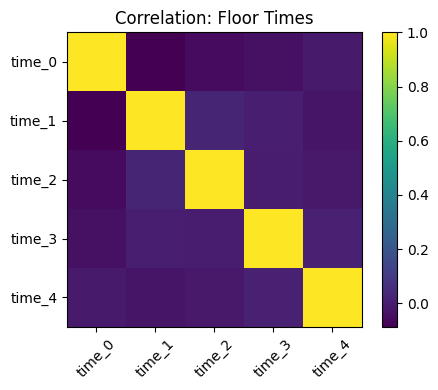

,time_0,time_1,time_2,time_3,time_4
time_0,1.000000,-0.086486,-0.053197,-0.039430,-0.007330
time_1,-0.086486,1.000000,0.025219,0.002927,-0.026073
time_2,-0.053197,0.025219,1.000000,-0.003320,-0.013631
time_3,-0.039430,0.002927,-0.003320,1.000000,0.014581
time_4,-0.007330,-0.026073,-0.013631,0.014581,1.000000


In [5]:

# Correlation heatmap among floor times
corr = df_raw[floors].corr()
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='viridis')
plt.xticks(range(len(floors)), floors, rotation=45); plt.yticks(range(len(floors)), floors)
plt.colorbar(); plt.title('Correlation: Floor Times')
plt.tight_layout(); plt.show()
corr



**EDA Highlights (to fill after running):**
- Typical visit duration range, presence of extreme outliers.  
- Which floors dominate overall time; correlations among floor totals.  
- Note if floor times sometimes sum to zero (invalid rows) — handled later.


## <a id='q1'></a> 3. Q1 — Filtering Employees & Short Visits

> **Rule:** Keep rows with `employee_flag == 0` **and** `duration ≥ 1800` seconds (30 minutes).

In [6]:

before = len(df_raw)
df = df_raw[(df_raw['employee_flag']==0) & (df_raw['duration']>=1800)].copy()
after = len(df)
print({'rows_before': before, 'rows_after': after, 'removed': before-after})
df[['employee_flag','duration']].describe(include='all')


{'rows_before': 7705, 'rows_after': 4832, 'removed': 2873}


,employee_flag,duration
count,4832.0,4832.000000
mean,0.0,11974.726821
std,0.0,10420.785333
min,0.0,1802.000000
25%,0.0,5078.000000
50%,0.0,8905.500000
75%,0.0,15632.000000
max,0.0,86372.000000



**Answer to Q1:** Employees and <30‑minute visits were removed as instructed. All subsequent steps use this filtered data.


## <a id='floors-fe'></a> 4. Feature Engineering for Floors (Percentages)

In [7]:

# Convert floor times to percentages (row-normalized)
floor_sum = df[floors].sum(axis=1).replace(0, np.nan)
for c in floors:
    df[c+'_pct'] = (df[c]/floor_sum)*100

# Drop rows that had 0 total floor time
df = df.dropna(subset=['time_0_pct']).copy()
X_floor = df[[c+'_pct' for c in floors]].to_numpy()
pd.DataFrame(X_floor, columns=[c+'_pct' for c in floors]).describe().T


,count,mean,std,min,25%,50%,75%,max
time_0_pct,4831.0,4.687208,18.320958,0.0,0.000000,0.000000,0.000000,100.0
time_1_pct,4831.0,39.858490,32.952874,0.0,8.269452,34.980717,66.681540,100.0
time_2_pct,4831.0,19.279617,24.598348,0.0,0.024744,8.935313,29.523122,100.0
time_3_pct,4831.0,29.261666,30.033374,0.0,1.022447,20.671618,46.945040,100.0
time_4_pct,4831.0,6.913019,19.722021,0.0,0.000000,0.000000,0.706628,100.0


## <a id='q2'></a> 5. Q2 — Floor-Based Segmentation (K‑Means)

### 5.1. Choose *K* via Elbow & Silhouette

In [8]:

cand = range(2,9)
rows = []
for k in cand:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lab = km.fit_predict(X_floor)
    rows.append({'k':k, 'silhouette': float(silhouette_score(X_floor, lab)), 'inertia': float(km.inertia_)})
res_k = pd.DataFrame(rows)
res_k


,k,silhouette,inertia
0,2,0.337108,1.067016e+07
1,3,0.405794,7.517847e+06
2,4,0.459554,5.353232e+06
3,5,0.502161,3.732493e+06
4,6,0.456843,2.768448e+06
5,7,0.427372,2.327121e+06
6,8,0.461806,1.979907e+06


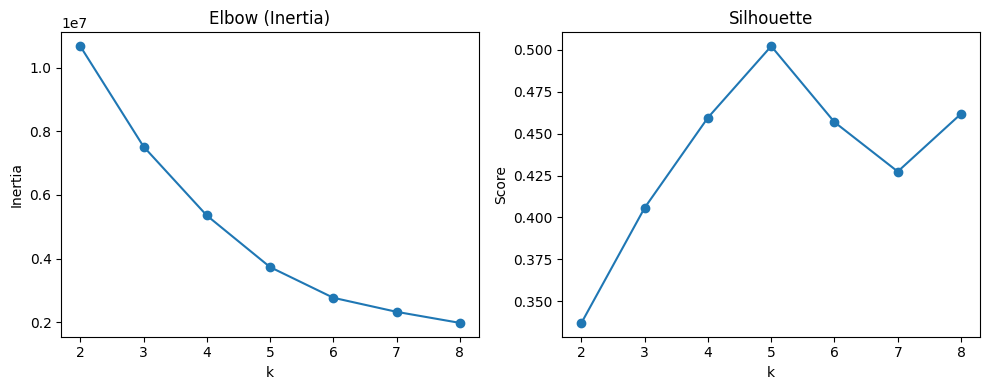

In [9]:

# Plot elbow & silhouette
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(res_k['k'], res_k['inertia'], marker='o'); ax[0].set_title('Elbow (Inertia)'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(res_k['k'], res_k['silhouette'], marker='o'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Score')
plt.tight_layout(); plt.show()


In [10]:

# Pick best K by silhouette (tie-break on lower inertia)
best = res_k.sort_values(['silhouette','inertia'], ascending=[False, True]).iloc[0]
K_FLOOR = int(best['k']); K_FLOOR, best


(5,
 k             5.000000e+00
 silhouette    5.021611e-01
 inertia       3.732493e+06
 Name: 3, dtype: float64)

### 5.2. Train Final Model & Label Data

In [11]:

km_floor = KMeans(n_clusters=K_FLOOR, n_init=50, random_state=42)
df['cluster_floor'] = km_floor.fit_predict(X_floor)

# Profiles
prof = df.groupby('cluster_floor')[[c+'_pct' for c in floors]].mean().round(2)
prof['count'] = df['cluster_floor'].value_counts().sort_index().values
prof


,time_0_pct,time_1_pct,time_2_pct,time_3_pct,time_4_pct,count
cluster_floor,,,,,,
0,0.99,75.52,8.81,12.95,1.74,1882
1,1.32,16.58,9.66,70.48,1.96,1348
2,0.85,22.16,58.26,16.63,2.10,1048
3,88.95,5.01,2.03,3.28,0.73,199
4,1.19,10.92,5.86,10.99,71.03,354


### 5.3. Cluster Profiling (Tables & Charts)

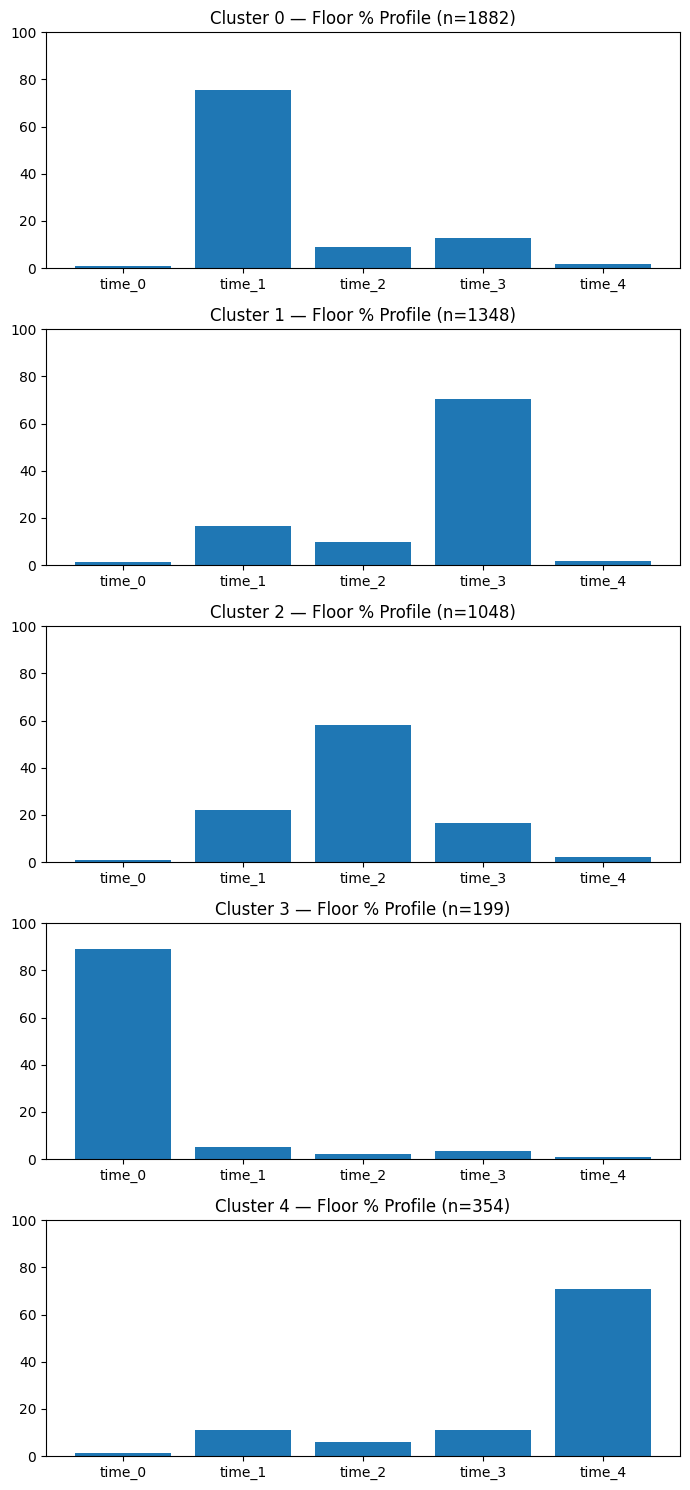

In [12]:

# Bar chart per cluster
cols = [c+'_pct' for c in floors]
fig, axes = plt.subplots(nrows=len(prof), ncols=1, figsize=(7, 3*len(prof)))
if len(prof)==1: axes = [axes]
for i,(idx,row) in enumerate(prof[cols].iterrows()):
    axes[i].bar(floors, row.values)
    axes[i].set_ylim(0, 100)
    axes[i].set_title(f'Cluster {idx} — Floor % Profile (n={prof.loc[idx, "count"]})')
plt.tight_layout(); plt.show()


### 5.4. PCA Visualization (2D)

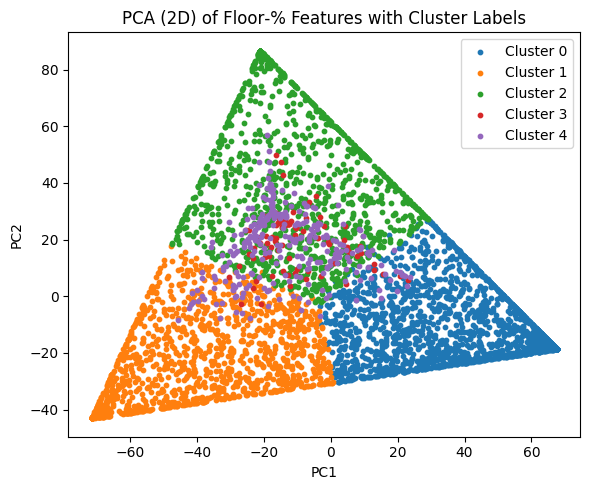

In [13]:

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_floor)
plt.figure(figsize=(6,5))
for k in sorted(df['cluster_floor'].unique()):
    m = df['cluster_floor']==k
    plt.scatter(X2[m,0], X2[m,1], s=10, label=f'Cluster {k}')
plt.legend(); plt.title('PCA (2D) of Floor‑% Features with Cluster Labels'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()



### 5.5. Interpretation
- **Chosen K:** `K_FLOOR` (see metrics table).  
- **Quality:** Highest Silhouette with elbow confirmation suggests stable separation.  
- **Profiles:** Use `prof` values to name clusters (e.g., **L1 Shoppers**, **L3 Leisure Goers**, **Explorers**, **Quick Errands/L0‑L4**).  


## <a id='q3'></a> 6. Q3 — Section-Level Sub‑Segmentation of Dominant-Floor Cluster

### 6.1. Pick Dominant Cluster & Floor

In [14]:

# Identify cluster & floor with the highest single-floor percentage (most floor-focused)
cent = prof[[c+'_pct' for c in floors]].to_numpy()
cl_idx, fl_idx = np.unravel_index(np.argmax(cent), cent.shape)
DOM_CLUSTER, DOM_FLOOR = int(cl_idx), int(fl_idx)
DOM_CLUSTER, DOM_FLOOR


(3, 0)

### 6.2. Feature Engineering (Section Percentages)

In [15]:

# Section columns for floors with sections (3 and/or 2)
sec_cols_map = {
    3: [c for c in df.columns if c.startswith('time_3_') and c!='time_3'],
    2: [c for c in df.columns if c.startswith('time_2_') and c!='time_2']
}
sec_cols = sec_cols_map.get(DOM_FLOOR, [])
if not sec_cols:
    # Fallback to floor 3 then 2 if chosen floor lacks sections in the dataset
    sec_cols = sec_cols_map.get(3, []) or sec_cols_map.get(2, [])
    DOM_FLOOR = 3 if sec_cols_map.get(3, []) else 2

df_sub = df[df['cluster_floor']==DOM_CLUSTER].copy()
sec_sum = df_sub[sec_cols].sum(axis=1).replace(0, np.nan)
for c in sec_cols:
    df_sub[c+'_pct'] = (df_sub[c]/sec_sum)*100
df_sub = df_sub.dropna(subset=[sec_cols[0]+'_pct']).copy()
X_sec = df_sub[[c+'_pct' for c in sec_cols]].to_numpy()

pd.DataFrame(X_sec, columns=[c+'_pct' for c in sec_cols]).describe().T


,count,mean,std,min,25%,50%,75%,max
time_3_e_pct,61.0,13.579808,29.635310,0.000000,0.000000,0.00000,9.325867,99.485332
time_3_n_pct,61.0,15.177705,29.999266,0.000000,0.000000,0.00000,10.277229,99.883961
time_3_ne_pct,61.0,5.524281,18.575545,0.000000,0.000000,0.00000,0.000000,99.884279
time_3_nex_pct,61.0,11.720172,28.438457,0.000000,0.000000,0.00000,0.000000,99.668017
time_3_nw_pct,61.0,4.653163,16.004196,0.000000,0.000000,0.00000,0.000000,99.772479
time_3_s_pct,61.0,24.614999,36.349412,0.000000,0.000000,0.00000,37.601066,99.715707
time_3_se_pct,61.0,4.513604,15.275624,0.000000,0.000000,0.00000,0.000000,93.916531
time_3_sw_pct,61.0,8.630183,17.655192,0.000000,0.000000,0.00000,4.676980,70.476111
time_3_w_pct,61.0,9.069094,23.797596,0.000000,0.000000,0.00000,0.000000,99.533452
time_3_pct_pct,61.0,2.516992,12.751311,0.115721,0.284949,0.48539,0.754489,100.000000


### 6.3. Choose *K*, Train, Profile, Visualize

In [16]:

cand2 = range(2,8)
rows2 = []
for k in cand2:
    km2 = KMeans(n_clusters=k, n_init=20, random_state=42)
    lab2 = km2.fit_predict(X_sec)
    rows2.append({'k':k, 'silhouette': float(silhouette_score(X_sec, lab2))})
res_k2 = pd.DataFrame(rows2)
res_k2


,k,silhouette
0,2,0.234339
1,3,0.326961
2,4,0.378720
3,5,0.455932
4,6,0.489966
5,7,0.522273


In [17]:

K_SEC = int(res_k2.sort_values(['silhouette','k'], ascending=[False, True]).iloc[0]['k'])
km_sec = KMeans(n_clusters=K_SEC, n_init=50, random_state=42)
df_sub['cluster_section'] = km_sec.fit_predict(X_sec)

prof_sec = df_sub.groupby('cluster_section')[[c+'_pct' for c in sec_cols]].mean().round(2)
prof_sec['count'] = df_sub['cluster_section'].value_counts().sort_index().values
prof_sec


,time_3_e_pct,time_3_n_pct,time_3_ne_pct,time_3_nex_pct,time_3_nw_pct,time_3_s_pct,time_3_se_pct,time_3_sw_pct,time_3_w_pct,time_3_pct_pct,count
cluster_section,,,,,,,,,,,
0,11.28,3.79,4.82,0.02,10.93,20.63,14.72,22.34,4.42,7.07,15
1,1.10,76.37,4.34,3.30,10.04,0.00,0.00,3.18,0.63,1.04,10
2,0.24,0.62,0.29,0.00,0.25,88.58,3.60,3.87,1.32,1.23,13
3,4.59,8.57,1.60,75.73,1.57,1.64,0.21,3.54,1.37,1.19,9
4,98.51,0.00,0.00,0.00,0.00,0.36,0.00,0.00,0.00,1.14,6
5,2.14,3.36,0.61,0.00,0.35,3.95,0.98,12.89,75.19,0.54,6
6,0.00,0.00,99.76,0.00,0.00,0.00,0.00,0.00,0.00,0.24,2


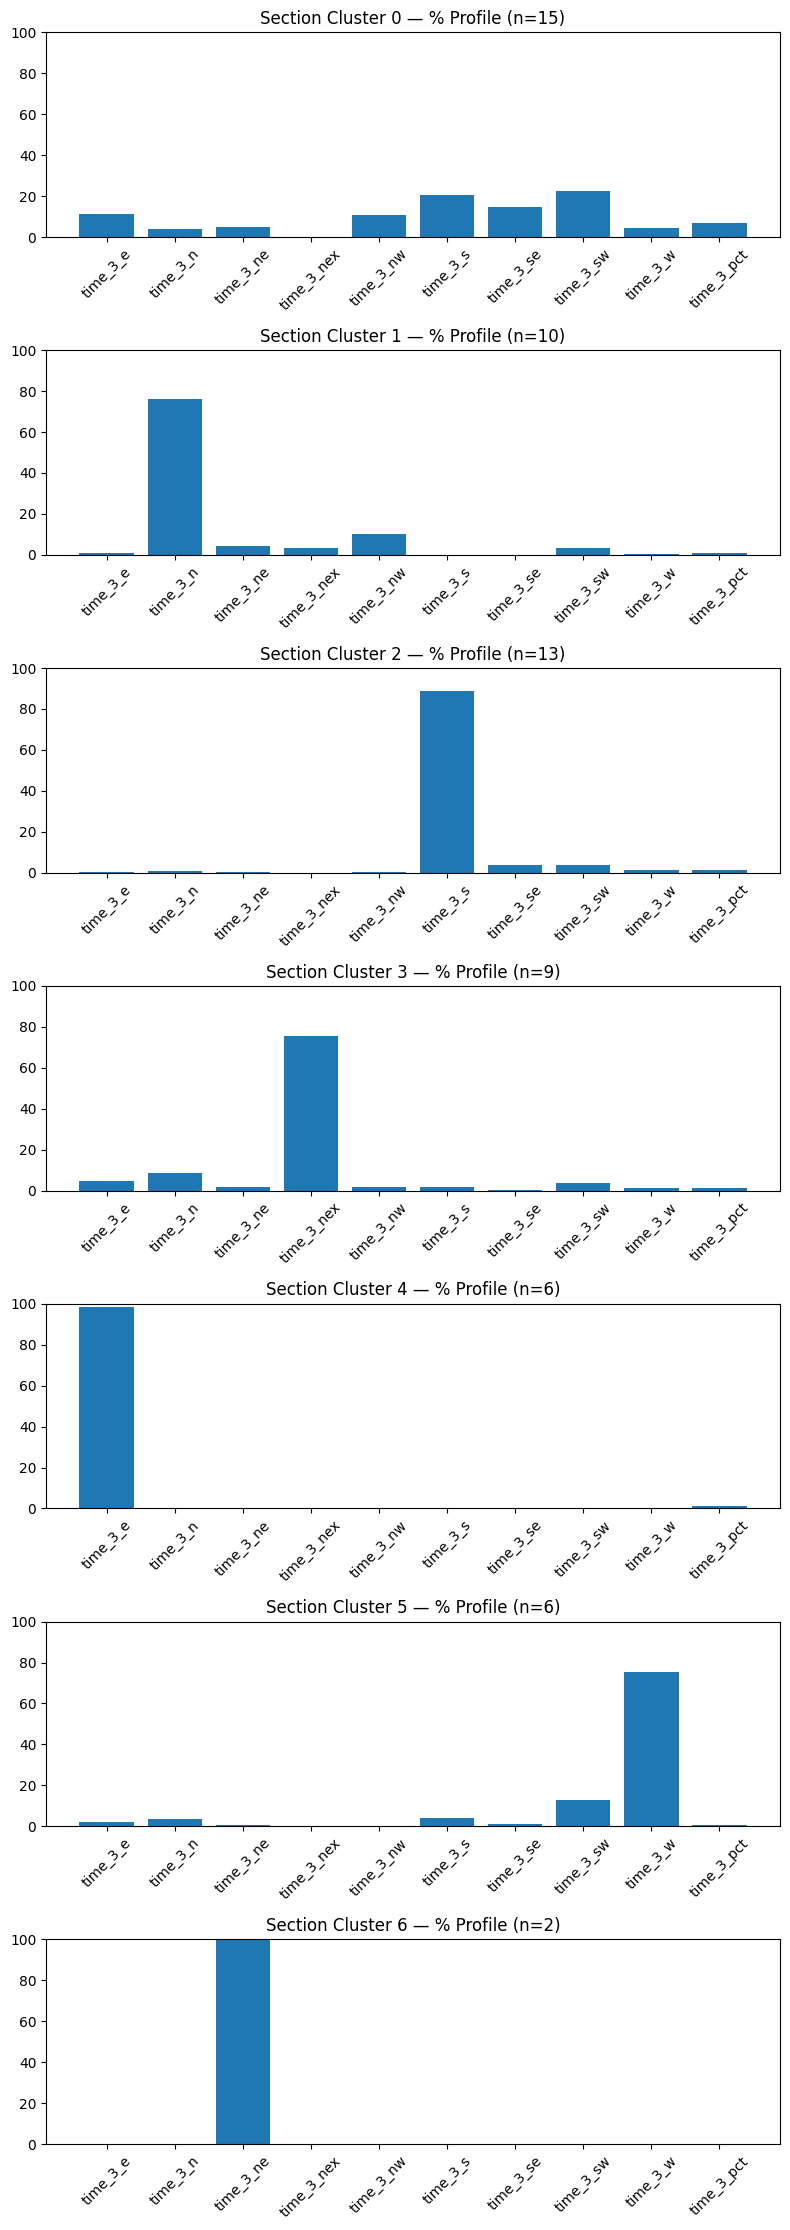

In [18]:

# Visualize section profiles
cols = [c+'_pct' for c in sec_cols]
fig, axes = plt.subplots(nrows=len(prof_sec), ncols=1, figsize=(8, 3.2*len(prof_sec)))
if len(prof_sec)==1: axes = [axes]
for i,(idx,row) in enumerate(prof_sec[cols].iterrows()):
    axes[i].bar(sec_cols, row.values)
    axes[i].set_ylim(0, 100)
    axes[i].set_title(f'Section Cluster {idx} — % Profile (n={prof_sec.loc[idx, "count"]})')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()



### 6.4. Interpretation
- **Chosen K (sections):** `K_SEC`.  
- Sub-clusters reveal **wing-level behavior** (e.g., **North/West = dining & entertainment**, **South/East = lifestyle retail**, **Extensions = anchor/cinema areas**). Use `prof_sec` to name them precisely.


## <a id='conclusion'></a> 7. Conclusions & Business Actions


- **Q1:** Filtering produced a clean shopper dataset (counts printed above).  
- **Q2:** Floor‑based clusters show distinct segments (e.g., L1 shoppers, L3 leisure, explorers, quick errands).  
- **Q3:** Within the most floor‑focused group, section‑level sub‑clusters surface **micro‑segments** by mall wings.

**Action ideas:**
1. **L3 leisure** → movie+dining bundles; evening promos.  
2. **L0/L4 quick errands** → parking guidance; fast checkout lanes; signage.  
3. **Explorers** → cross‑category coupons and wayfinding nudges across L1+L2.  
4. **Wing‑specific** offers for section clusters (e.g., food court vs lifestyle corridors).
